# 03. Регрессия для CC50

В данном ноутбуке решается задача регрессии для прогнозирования значения `CC50, mM`.

Цель работы — подготовить данные, обучить несколько моделей машинного обучения, сравнить их качество по метрикам регрессии и сделать вывод о применимости разных подходов.

In [1]:
# 1. Импорт библиотек

# Импортируем pandas для работы с табличными данными
import pandas as pd

# Импортируем numpy для численных расчётов
import numpy as np

# Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем StandardScaler для стандартизации признаков
from sklearn.preprocessing import StandardScaler

# Импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# Импортируем случайный лес для задачи регрессии
from sklearn.ensemble import RandomForestRegressor

# Импортируем градиентный бустинг для задачи регрессии
from sklearn.ensemble import GradientBoostingRegressor

# Импортируем метрики качества регрессии
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Импортируем GridSearchCV для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Импортируем warnings, чтобы убрать лишние предупреждения
import warnings

# Отключаем предупреждения для более аккуратного вывода
warnings.filterwarnings('ignore')

In [2]:
# 2. Загрузка обработанного датасета

# Импортируем files из Google Colab для загрузки файла с компьютера
from google.colab import files

# Загружаем обработанный CSV-файл, который был сохранён после EDA
uploaded = files.upload()

Saving processed_chemical_data.csv to processed_chemical_data.csv


In [3]:
# 3. Чтение обработанного датасета

# Считываем обработанный CSV-файл в переменную df
df = pd.read_csv('processed_chemical_data.csv')

# Проверяем, есть ли в датасете технический столбец с индексом
if 'Unnamed: 0' in df.columns:

    # Удаляем технический столбец, так как он не является химическим признаком
    df = df.drop(columns=['Unnamed: 0'])

# Выводим первые 5 строк, чтобы проверить корректность загрузки
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 4. Подготовка признаков и целевой переменной

# Создаём список целевых переменных, которые не должны попадать в признаки
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

# Формируем матрицу признаков X: удаляем из данных все целевые переменные
X = df.drop(columns=target_columns)

# Формируем целевую переменную y для задачи регрессии CC50
y = df['CC50, mM']

# Проверяем размерность матрицы признаков
print('Размер X:', X.shape)

# Проверяем размерность целевой переменной
print('Размер y:', y.shape)

Размер X: (1001, 210)
Размер y: (1001,)


In [5]:
# 5. Разделение данных на обучающую и тестовую выборки

# Делим данные на обучающую и тестовую выборки в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Выводим размер обучающей выборки
print('Размер X_train:', X_train.shape)

# Выводим размер тестовой выборки
print('Размер X_test:', X_test.shape)

Размер X_train: (800, 210)
Размер X_test: (201, 210)


In [6]:
# 6. Стандартизация признаков

# Создаём объект StandardScaler для приведения признаков к единому масштабу
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке и сразу преобразуем X_train
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовую выборку с помощью scaler, обученного на X_train
X_test_scaled = scaler.transform(X_test)

# Проверяем размерность стандартизированной обучающей выборки
print('Размер X_train_scaled:', X_train_scaled.shape)

# Проверяем размерность стандартизированной тестовой выборки
print('Размер X_test_scaled:', X_test_scaled.shape)

Размер X_train_scaled: (800, 210)
Размер X_test_scaled: (201, 210)


In [7]:
# 7. Обучение базовых моделей регрессии

# Создаём словарь моделей, которые будем сравнивать между собой
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Создаём пустой список для сохранения результатов моделей
results = []

# Запускаем цикл по всем моделям из словаря
for model_name, model in models.items():

    # Для линейной регрессии используем стандартизированные признаки
    if model_name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Для древовидных моделей используем обычные признаки без стандартизации
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Считаем MAE — среднюю абсолютную ошибку
    mae = mean_absolute_error(y_test, y_pred)

    # Считаем RMSE — корень из среднеквадратичной ошибки
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Считаем R2 — коэффициент детерминации
    r2 = r2_score(y_test, y_pred)

    # Добавляем результаты текущей модели в общий список
    results.append([model_name, mae, rmse, r2])

# Создаём таблицу с результатами сравнения моделей
results_df = pd.DataFrame(results, columns=['Модель', 'MAE', 'RMSE', 'R2'])

# Выводим таблицу результатов
results_df

,Модель,MAE,RMSE,R2
0,Linear Regression,391.773527,581.384153,0.348042
1,Random Forest,286.291744,459.060404,0.593526
2,Gradient Boosting,296.767076,466.123468,0.580922


In [8]:
# 8. Сортировка моделей по качеству

# Сортируем модели по метрике R2: чем выше R2, тем лучше модель
results_df.sort_values(by='R2', ascending=False)

,Модель,MAE,RMSE,R2
1,Random Forest,286.291744,459.060404,0.593526
2,Gradient Boosting,296.767076,466.123468,0.580922
0,Linear Regression,391.773527,581.384153,0.348042


In [9]:
# 9. Подбор гиперпараметров для Random Forest

# Задаём модель Random Forest для подбора гиперпараметров
rf_model = RandomForestRegressor(random_state=42)

# Задаём сетку гиперпараметров для перебора
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Создаём объект GridSearchCV для поиска лучшей комбинации параметров
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1
)

# Обучаем GridSearchCV на обучающей выборке
grid_search.fit(X_train, y_train)

# Выводим лучшие найденные параметры
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

In [10]:
# 10. Оценка лучшей модели Random Forest

# Сохраняем лучшую модель после подбора гиперпараметров
best_rf_model = grid_search.best_estimator_

# Делаем прогноз на тестовой выборке
y_pred_best_rf = best_rf_model.predict(X_test)

# Считаем MAE для лучшей модели
best_rf_mae = mean_absolute_error(y_test, y_pred_best_rf)

# Считаем RMSE для лучшей модели
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

# Считаем R2 для лучшей модели
best_rf_r2 = r2_score(y_test, y_pred_best_rf)

# Выводим результаты лучшей модели
print('MAE:', best_rf_mae)
print('RMSE:', best_rf_rmse)
print('R2:', best_rf_r2)

MAE: 286.18396455294743
RMSE: 459.4864655365132
R2: 0.5927712539210241


### Вывод по подбору гиперпараметров

Для задачи регрессии `CC50, mM` были обучены и сравнены несколько моделей: Linear Regression, Random Forest и Gradient Boosting.

Лучший результат среди базовых моделей показала модель Random Forest. После подбора гиперпараметров качество модели существенно не изменилось: значение R2 осталось примерно на том же уровне.

Это говорит о том, что Random Forest является наиболее устойчивым решением среди рассмотренных моделей для прогнозирования `CC50, mM`. Для дальнейшего улучшения качества можно рассмотреть более широкий подбор гиперпараметров, отбор признаков или дополнительные методы feature engineering.

In [11]:
# 12. Анализ важности признаков

# Обучаем итоговую модель Random Forest на обучающей выборке
final_rf_model = RandomForestRegressor(random_state=42)

# Обучаем модель на исходных признаках
final_rf_model.fit(X_train, y_train)

# Получаем важности признаков из обученной модели
feature_importances = final_rf_model.feature_importances_

# Создаём таблицу с названиями признаков и их важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importances
})

# Сортируем признаки по важности по убыванию
importance_df = importance_df.sort_values(by='Важность', ascending=False)

# Выводим 15 наиболее важных признаков
importance_df.head(15)

,Признак,Важность
46,LabuteASA,0.057184
19,BCUT2D_MWLOW,0.043937
32,Chi1,0.038881
45,Kappa3,0.037997
44,Kappa2,0.037968
15,FpDensityMorgan1,0.034707
25,BCUT2D_MRLOW,0.030406
124,MolMR,0.028266
42,Ipc,0.023907
16,FpDensityMorgan2,0.021910


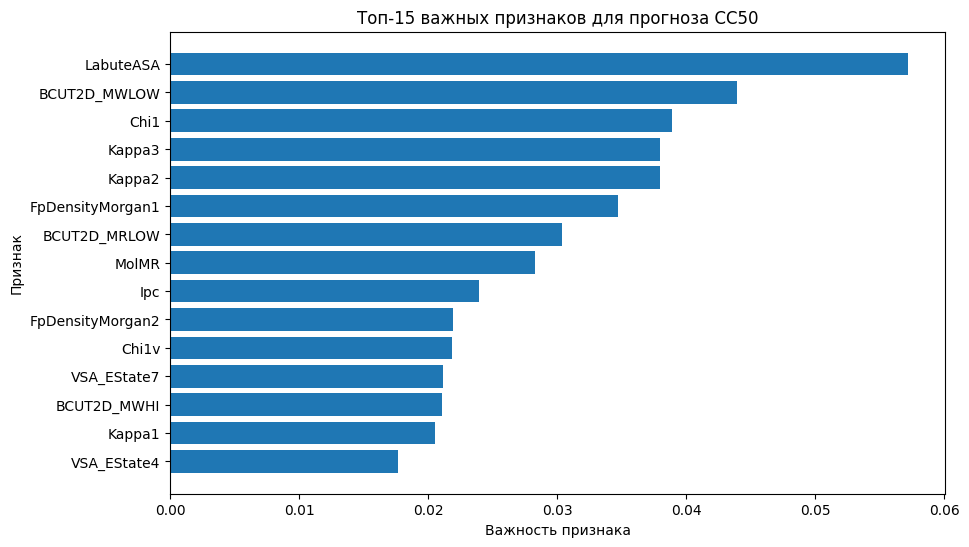

In [12]:
# 13. Визуализация важности признаков

# Берём 15 наиболее важных признаков
top_features = importance_df.head(15)

# Строим горизонтальный график важности признаков
plt.figure(figsize=(10, 6))
plt.barh(top_features['Признак'], top_features['Важность'])
plt.gca().invert_yaxis()
plt.title('Топ-15 важных признаков для прогноза CC50')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()

### Вывод по важности признаков

Для итоговой модели Random Forest была рассчитана важность признаков.

Наиболее значимыми признаками для прогноза `CC50, mM` оказались молекулярные дескрипторы `LabuteASA`, `BCUT2D_MWLOW`, `Chi1`, `Kappa3`, `Kappa2`, `FpDensityMorgan1` и другие.

Это показывает, что модель использует разные группы химических характеристик соединений. Важность признаков помогает понять, какие параметры сильнее всего влияли на прогноз модели, однако не является доказательством прямой причинно-следственной связи.

### Итоговый вывод по задаче регрессии CC50

В данном ноутбуке была решена задача регрессии для прогнозирования значения `CC50, mM`.

Были выполнены следующие этапы:

- загружен обработанный после EDA датасет;
- удалён технический столбец `Unnamed: 0`, не являющийся химическим признаком;
- данные были разделены на обучающую и тестовую выборки;
- для линейной модели была выполнена стандартизация признаков;
- обучены и сравнены модели Linear Regression, Random Forest и Gradient Boosting;
- выполнен подбор гиперпараметров для Random Forest;
- рассчитана важность признаков для итоговой модели.

По результатам сравнения моделей лучшую метрику R2 показала модель Random Forest. Gradient Boosting также показал близкий результат, а Linear Regression оказалась менее точной.

Подбор гиперпараметров Random Forest не дал существенного улучшения качества на тестовой выборке. Поэтому в рамках данной задачи наиболее устойчивым решением можно считать Random Forest.

Для дальнейшего улучшения качества прогноза можно рассмотреть более широкий подбор гиперпараметров, отбор признаков, логарифмирование целевой переменной или применение дополнительных методов feature engineering.